# Disease Spread Simulation Using the SIR Model

## Introduction

Understanding how diseases spread through a population is an important problem in public health, epidemiology, and mathematical modelling. Infectious diseases can spread rapidly and affect large numbers of people, making it essential to understand the factors that influence transmission and recovery.

Mathematical models provide a way to study disease outbreaks without performing real-world experiments. By combining mathematics and computer simulations, researchers can examine how diseases progress over time and evaluate the potential impact of interventions such as vaccination and improved recovery measures.

This project uses the Susceptible-Infected-Recovered (SIR) model to simulate the spread of an infectious disease within a population. The model is implemented in Python and solved numerically to track changes in susceptible, infected, and recovered individuals over time. The results are visualized using graphs to provide insight into disease dynamics and epidemic behaviour.

## Research Question

How do changes in infection rate, recovery rate, and vaccination coverage affect the size and duration of a disease outbreak in a simulated population?

## Project Objectives

The main objectives of this project are:

* Implement the SIR epidemiological model in Python.
* Simulate disease spread within a population over time.
* Visualize changes in susceptible, infected, and recovered populations.
* Analyze the effects of infection and recovery rates on disease transmission.
* Demonstrate the application of mathematical modelling and scientific computing to a real-world problem.

## Methodology

The project uses the classical SIR model, which divides a population into three categories:

* **Susceptible (S):** Individuals who can become infected.
* **Infected (I):** Individuals who currently have the disease and can transmit it.
* **Recovered (R):** Individuals who have recovered and are assumed to have immunity.

The interactions between these groups are described by a system of differential equations. Numerical methods are used to solve these equations and simulate how the disease evolves over time.

Python libraries including NumPy, SciPy, and Matplotlib are used for numerical computation, simulation, and visualization of results.

## Expected Outcomes

The simulation is expected to demonstrate the following behaviours:

* The susceptible population decreases as more individuals become infected.
* The infected population initially grows as the disease spreads through the population.
* The infected population eventually reaches a peak before declining as recovery increases.
* The recovered population increases steadily throughout the simulation.
* Different infection and recovery rates lead to significantly different outbreak patterns.

The project will provide a visual and mathematical understanding of how diseases spread and how model parameters influence epidemic outcomes.

## Skills Demonstrated

This project demonstrates skills in:

* Python Programming
* Mathematical Modelling
* Differential Equations
* Scientific Computing
* Numerical Methods
* Data Visualization
* Problem Solving
* Data Analysis
* Research and Technical Communication

---

## Import Libraries


In [1]:
import numpy as np                                         # NumPy (np) = used for numbers, arrays, and math operations
import matplotlib.pyplot as plt                            # Matplotlib (plt) = used to create charts (line, bar, scatter, etc.)

from scipy.integrate import odeint                         # SciPy (odeint) = Solve the SIR differential equations

## Model Description

The **Susceptible-Infected-Recovered (SIR) model** is a mathematical model used to study how an infectious disease spreads through a population.

The model divides the population into three groups:

| Group | Meaning |
|---|---|
| **S** | Susceptible individuals who can catch the disease |
| **I** | Infected individuals who currently have the disease and can spread it |
| **R** | Recovered individuals who have recovered and are assumed to have immunity |

The model assumes that the total population stays constant during the simulation. People move from:

**Susceptible → Infected → Recovered**

The total population is:

$$
N = S + I + R
$$

---

## Variables

| Variable | Meaning |
|---|---|
| **S** | Number of susceptible individuals |
| **I** | Number of infected individuals |
| **R** | Number of recovered individuals |
| **N** | Total population size |
| **β** | Infection rate |
| **γ** | Recovery rate |
| **t** | Time |

---

## Model Equations

The SIR model is represented by these differential equations:

$$
\frac{dS}{dt} = -\beta \frac{SI}{N}
$$

$$
\frac{dI}{dt} = \beta \frac{SI}{N} - \gamma I
$$

$$
\frac{dR}{dt} = \gamma I
$$

---

## Equation Interpretation

The first equation shows how the susceptible population decreases as people become infected.

The second equation shows how the infected population changes. It increases when new people become infected and decreases when infected people recover.

The third equation shows how the recovered population increases as infected people recover.

In [3]:
# Define the SIR model function
def sir_model(y, t, N, beta, gamma):
    """
    This function defines the SIR model.

    Parameters:
    y: list or tuple containing S, I, and R values
    t: time
    N: total population
    beta: infection rate
    gamma: recovery rate

    Returns:
    dSdt, dIdt, dRdt: rate of change for each group
    """

    S, I, R = y

    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I

    return dSdt, dIdt, dRdt

### Explanation of the SIR Model Function

The `sir_model()` function defines the mathematical equations used to simulate the spread of a disease through a population. The function takes the current numbers of susceptible (S), infected (I), and recovered (R) individuals and calculates how these values change over time.

The parameter `beta` represents the infection rate. It determines how quickly susceptible individuals become infected after coming into contact with infected individuals. The parameter `gamma` represents the recovery rate and determines how quickly infected individuals recover from the disease.

The first equation calculates the rate at which susceptible individuals become infected. As more people become infected, the susceptible population decreases.

The second equation calculates the rate of change in the infected population. This value increases when new infections occur and decreases when infected individuals recover.

The third equation calculates the rate at which infected individuals recover and move into the recovered category.

The function returns the rates of change for all three groups. These values are then used by the numerical solver to simulate how the disease spreads throughout the population over time.


In [4]:
# Total population
N = 1000

# Initial number of infected and recovered individuals
I0 = 1
R0 = 0

# Everyone else is initially susceptible
S0 = N - I0 - R0

# Infection rate
beta = 0.3

# Recovery rate
gamma = 0.1

# Number of days to simulate
days = 160

# Time points
t = np.linspace(0, days, days)

# Initial conditions
initial_conditions = S0, I0, R0

### Explanation of Initial Parameters

This section defines the starting conditions and parameters used in the simulation.

The total population (`N`) is set to 1,000 individuals. At the beginning of the simulation, only one person is infected (`I0 = 1`) and no individuals have recovered (`R0 = 0`). The remaining members of the population are considered susceptible to infection (`S0 = N - I0 - R0`).

The infection rate (`β = 0.3`) determines how quickly the disease spreads through contact between susceptible and infected individuals. A higher infection rate would result in a faster spread of the disease.

The recovery rate (`γ = 0.1`) determines how quickly infected individuals recover and move into the recovered category. A higher recovery rate would reduce the duration of infection and slow the spread of the disease.

The simulation is run over a period of 160 days. The `np.linspace()` function creates evenly spaced time points across this period, allowing the model to calculate changes in the population at each step.

Finally, the initial conditions `(S0, I0, R0)` are grouped together and supplied to the numerical solver. These values represent the starting state of the population before the disease begins to spread.


In [5]:
# Solve the system of differential equations
solution = odeint(
    sir_model,
    initial_conditions,
    t,
    args=(N, beta, gamma)
)

# Separate the solution into S, I, and R values
S, I, R = solution.T

### Explanation of the Simulation

The `odeint()` function from the SciPy library is used to numerically solve the system of differential equations that define the SIR model. Because the equations describe how the susceptible, infected, and recovered populations change continuously over time, a numerical solver is needed to approximate their values at each time point.

The solver takes four main inputs: the SIR model function, the initial conditions, the time period being simulated, and the model parameters (population size, infection rate, and recovery rate). It then calculates the number of susceptible, infected, and recovered individuals for every day in the simulation.

The result is stored in the variable `solution`, which contains all calculated values produced by the model. The line `S, I, R = solution.T` separates the results into three individual arrays representing the susceptible, infected, and recovered populations. These arrays are later used to create graphs and analyze how the disease spreads through the population over time.


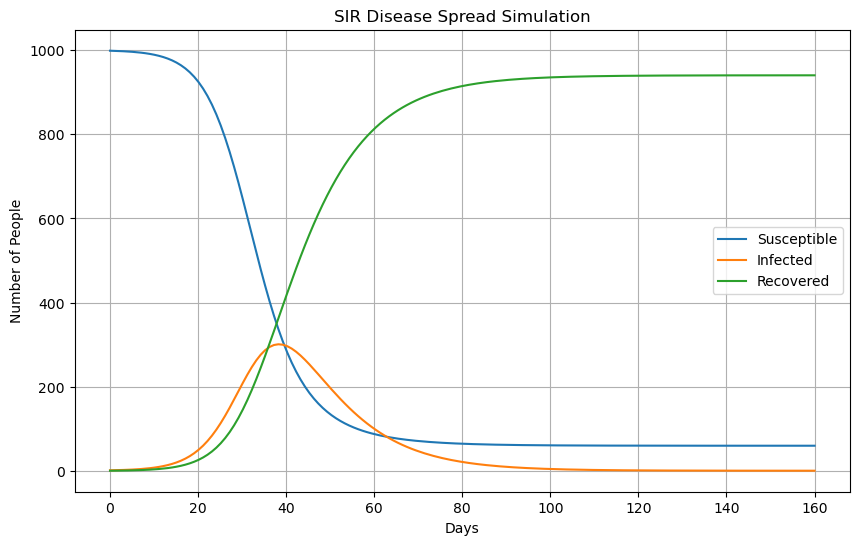

In [18]:
# Create the plot
plt.figure(figsize=(10, 6))

plt.plot(t, S, label="Susceptible")
plt.plot(t, I, label="Infected")
plt.plot(t, R, label="Recovered")

plt.xlabel("Days")
plt.ylabel("Number of People")
plt.title("SIR Disease Spread Simulation")
plt.legend()
plt.grid(True)

plt.show()

### Explanation of the Visualization Code

This section of code creates a visual representation of the SIR simulation results. The purpose of the graph is to show how the susceptible, infected, and recovered populations change over time during the outbreak.

The `plt.figure(figsize=(10, 6))` command creates a plotting area that is 10 inches wide and 6 inches tall, providing enough space for the data to be displayed clearly.

The `plt.plot()` commands draw three separate lines on the graph:

* `plt.plot(t, S, label="Susceptible")` plots the number of susceptible individuals over time.
* `plt.plot(t, I, label="Infected")` plots the number of infected individuals over time.
* `plt.plot(t, R, label="Recovered")` plots the number of recovered individuals over time.

The x-axis is labelled "Days" to represent the progression of time throughout the simulation. The y-axis is labelled "Number of People" to show the size of each population group at a given time.

A title is added to clearly identify the graph as a disease spread simulation. The legend helps distinguish between the susceptible, infected, and recovered populations, while the grid improves readability by making trends easier to observe.

Finally, `plt.show()` displays the completed graph.

### Explanation of the Output

The output of this code is a line graph containing three curves representing the susceptible, infected, and recovered populations.

The susceptible curve begins at a high value because almost the entire population is initially vulnerable to infection. As the disease spreads, this curve decreases because individuals move from the susceptible group into the infected group.

The infected curve starts near zero because only one individual is infected at the beginning of the simulation. As transmission occurs, the number of infected individuals increases and eventually reaches a peak. After this peak, the infected population decreases as more people recover and fewer susceptible individuals remain.

The recovered curve begins at zero and steadily increases throughout the simulation. This occurs because infected individuals gradually recover and move into the recovered category.

The graph illustrates the typical lifecycle of an epidemic. Initially, infections grow slowly, followed by a rapid increase in cases. The outbreak eventually reaches a peak before declining as recovery becomes more common and the pool of susceptible individuals decreases. This behavior demonstrates how mathematical models can be used to understand and predict disease dynamics in a population.


## Experiment 1: Effect of Infection Rate

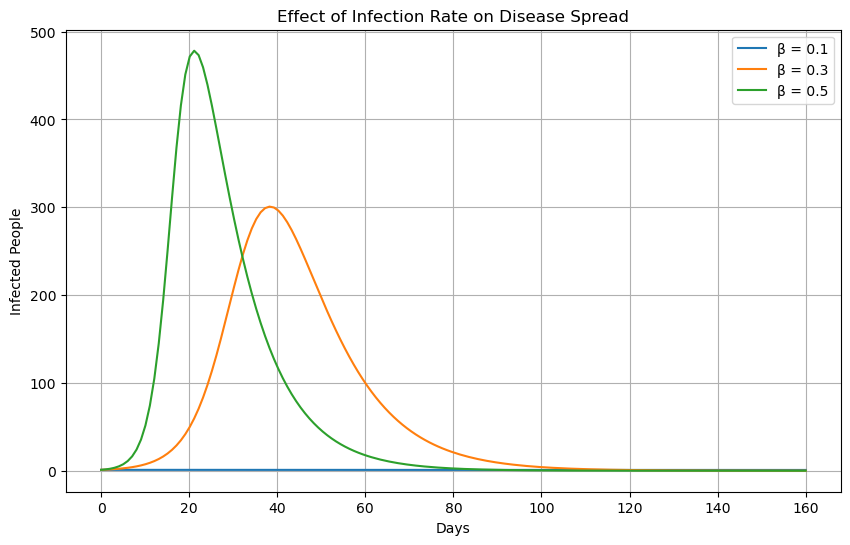

In [7]:
beta_values = [0.1, 0.3, 0.5]

plt.figure(figsize=(10, 6))

for beta in beta_values:

    solution = odeint(
        sir_model,
        initial_conditions,
        t,
        args=(N, beta, gamma)
    )

    S, I, R = solution.T

    plt.plot(t, I, label=f"β = {beta}")

plt.xlabel("Days")
plt.ylabel("Infected People")
plt.title("Effect of Infection Rate on Disease Spread")
plt.legend()
plt.grid(True)

plt.show()

## Results and Discussion: Effect of Infection Rate

This experiment investigates how different infection rates (β) affect the spread of a disease within a population. The infection rate represents the likelihood that a susceptible individual becomes infected after coming into contact with an infected individual.

Three infection rates were tested:

- β = 0.1 (low transmission)
- β = 0.3 (moderate transmission)
- β = 0.5 (high transmission)

The results show that as the infection rate increases, the disease spreads more quickly through the population. Higher values of β produce a larger number of infected individuals and cause the outbreak to reach its peak earlier.

For β = 0.1, the outbreak develops slowly and affects fewer people at any given time. For β = 0.3, the disease spreads more rapidly and reaches a higher peak. For β = 0.5, the infection spreads very quickly, producing the largest outbreak and the earliest peak number of infections.

These results demonstrate that the infection rate is one of the most important factors influencing disease transmission. Measures that reduce transmission, such as vaccination, social distancing, or improved hygiene practices, can significantly reduce the severity of an outbreak.

### Key Observation

As the infection rate increases, both the speed of disease transmission and the peak number of infected individuals increase.

## Experiment 2: Effect of Recovery Rate

The recovery rate (γ) represents the proportion of infected individuals who recover from the disease during a given period of time. A higher recovery rate means that infected individuals recover more quickly, reducing the amount of time they can transmit the disease to others.

This experiment investigates how different recovery rates affect the spread and duration of an outbreak. By comparing multiple recovery rates, we can better understand the role of recovery in controlling disease transmission.

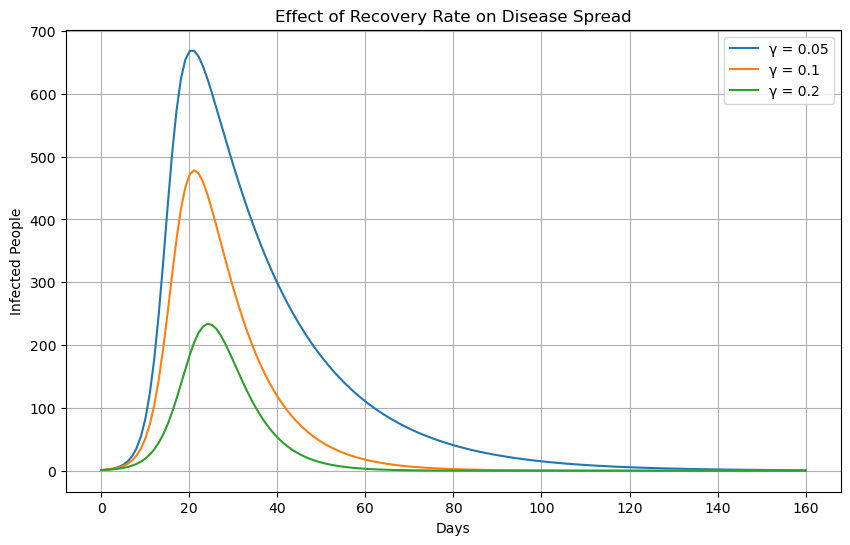

In [8]:
gamma_values = [0.05, 0.1, 0.2]

plt.figure(figsize=(10, 6))

for gamma in gamma_values:

    solution = odeint(
        sir_model,
        initial_conditions,
        t,
        args=(N, beta, gamma)
    )

    S, I, R = solution.T

    plt.plot(t, I, label=f"γ = {gamma}")

plt.xlabel("Days")
plt.ylabel("Infected People")
plt.title("Effect of Recovery Rate on Disease Spread")
plt.legend()
plt.grid(True)

plt.show()

## Results and Discussion: Effect of Recovery Rate

This experiment examines how changes in the recovery rate (γ) influence the progression of a disease outbreak. The recovery rate determines how quickly infected individuals move into the recovered category.

Three recovery rates were tested:

- γ = 0.05 (slow recovery)
- γ = 0.1 (moderate recovery)
- γ = 0.2 (fast recovery)

The results show that increasing the recovery rate reduces both the size and duration of the outbreak. When recovery occurs more quickly, infected individuals spend less time spreading the disease, resulting in fewer overall infections.

For γ = 0.05, infected individuals recover slowly, allowing the disease to spread for a longer period and producing a larger outbreak. For γ = 0.1, the outbreak is more controlled. For γ = 0.2, infected individuals recover rapidly, leading to a lower peak number of infections and a shorter outbreak duration.

These findings demonstrate that improving recovery rates can significantly reduce the impact of an epidemic. Effective treatments and healthcare interventions can therefore play an important role in controlling disease spread.

### Key Observation

As the recovery rate increases, the peak number of infected individuals decreases and the outbreak ends more quickly.

## Experiment 3: Effect of Vaccination

Vaccination is one of the most effective methods for preventing the spread of infectious diseases. In the SIR model, vaccinated individuals can be represented as part of the recovered population because they are assumed to be immune to infection.

This experiment investigates how different levels of vaccination coverage affect the size and duration of a disease outbreak. By comparing multiple vaccination scenarios, we can evaluate the effectiveness of vaccination as a disease control strategy.

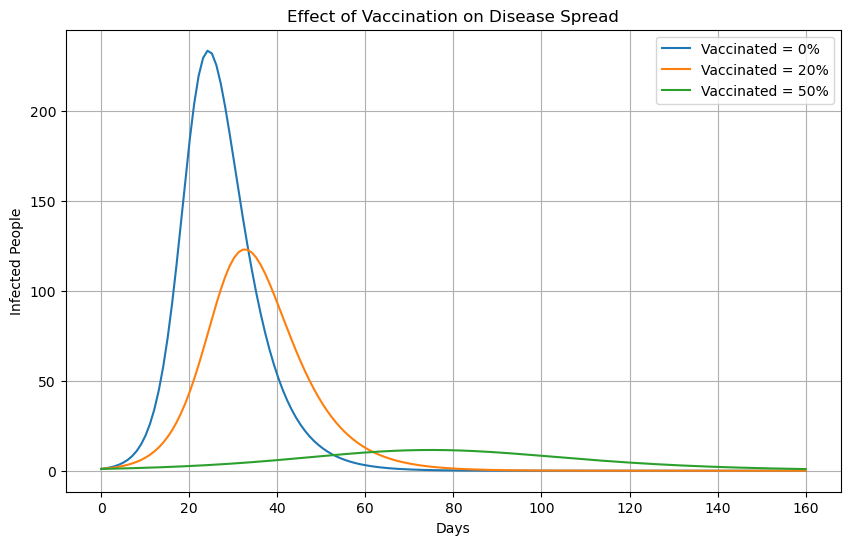

In [9]:
vaccination_rates = [0.0, 0.2, 0.5]

plt.figure(figsize=(10, 6))

for vaccination_rate in vaccination_rates:

    vaccinated = int(N * vaccination_rate)

    S0_vacc = N - I0 - vaccinated
    R0_vacc = vaccinated

    initial_conditions_vacc = (S0_vacc, I0, R0_vacc)

    solution = odeint(
        sir_model,
        initial_conditions_vacc,
        t,
        args=(N, beta, gamma)
    )

    S, I, R = solution.T

    plt.plot(
        t,
        I,
        label=f"Vaccinated = {int(vaccination_rate*100)}%"
    )

plt.xlabel("Days")
plt.ylabel("Infected People")
plt.title("Effect of Vaccination on Disease Spread")
plt.legend()
plt.grid(True)

plt.show()

## Results and Discussion: Effect of Vaccination

This experiment investigates how different levels of vaccination coverage influence the spread of an infectious disease. Vaccinated individuals are assumed to have immunity and therefore begin in the recovered category of the SIR model.

Three vaccination scenarios were examined:

- 0% vaccinated
- 20% vaccinated
- 50% vaccinated

The results show that increasing vaccination coverage significantly reduces the severity of the outbreak. As more individuals are vaccinated, fewer susceptible people remain available for infection, limiting the ability of the disease to spread through the population.

With no vaccination, the outbreak reaches its highest peak and affects the greatest number of individuals. When 20% of the population is vaccinated, the outbreak becomes smaller and progresses more slowly. At 50% vaccination coverage, the number of infected individuals is substantially reduced and the outbreak is much more controlled.

These findings demonstrate the importance of vaccination as a public health intervention. By reducing the number of susceptible individuals, vaccination decreases disease transmission and helps protect the wider population.

### Key Observation

Higher vaccination coverage leads to fewer infections, a lower outbreak peak, and a shorter outbreak duration.

## Summary of Findings

This project investigated how infection rate, recovery rate, and vaccination coverage affect the spread of an infectious disease using the SIR model.

The baseline simulation demonstrated the typical behaviour of an epidemic. The susceptible population decreased over time as individuals became infected. The infected population initially increased, reached a peak, and then declined as more individuals recovered. The recovered population increased steadily throughout the simulation.

The infection rate experiment showed that higher infection rates result in faster disease transmission and larger outbreaks. As the value of β increased, the number of infected individuals rose more rapidly and reached a higher peak. This indicates that highly contagious diseases can spread quickly through a population if no control measures are implemented.

The recovery rate experiment demonstrated that faster recovery reduces the severity of an outbreak. Higher values of γ led to fewer infected individuals at any given time and shortened the duration of the epidemic. This highlights the importance of effective medical treatment and healthcare interventions.

The vaccination experiment showed that increasing vaccination coverage significantly reduces disease transmission. As more individuals were vaccinated, fewer people remained susceptible to infection, resulting in smaller outbreaks and lower peak infection levels.

Overall, the results indicate that disease spread is strongly influenced by infection rate, recovery rate, and vaccination coverage. Strategies that reduce transmission, increase recovery, or improve vaccination uptake can substantially decrease the impact of an epidemic.

### Answer to the Research Question

The simulation demonstrates that higher infection rates increase both the speed and severity of disease outbreaks, while higher recovery rates and greater vaccination coverage reduce the number of infections and shorten outbreak duration. Among the factors examined, vaccination proved to be one of the most effective methods for limiting disease spread within the population.

## Comparison of All Scenarios

This section compares the outcomes of the three experiments conducted in this project: infection rate, recovery rate, and vaccination coverage.

| Factor Investigated | Effect on Disease Spread |
|---------------------|--------------------------|
| Infection Rate (β) | Higher infection rates produced faster and larger outbreaks. The peak number of infected individuals increased as transmission became more likely. |
| Recovery Rate (γ) | Higher recovery rates reduced the number of infected individuals and shortened the duration of the outbreak. |
| Vaccination Coverage | Higher vaccination coverage significantly reduced disease transmission by decreasing the number of susceptible individuals. |

The experiments demonstrated that all three factors play an important role in determining disease dynamics. However, vaccination had the greatest overall impact on reducing the size of the outbreak because it directly reduced the number of individuals who could become infected.

The infection rate primarily influenced how quickly the disease spread through the population, while the recovery rate affected how long infected individuals remained capable of transmitting the disease. Vaccination provided the strongest preventative effect by reducing the pool of susceptible individuals before the outbreak began.

These findings are consistent with epidemiological theory and highlight the importance of combining prevention, treatment, and public health interventions to control infectious diseases.

## Baseline Simulation Metrics

In [15]:
beta = 0.3
gamma = 0.1

solution = odeint(
    sir_model,
    initial_conditions,
    t,
    args=(N, beta, gamma)
)

S, I, R = solution.T

In [16]:
peak_infected = max(I)
peak_day = t[np.argmax(I)]
final_recovered = R[-1]

threshold = 1
outbreak_days = np.where(I > threshold)[0]

if len(outbreak_days) > 0:
    outbreak_duration = outbreak_days[-1] - outbreak_days[0]
else:
    outbreak_duration = 0

print(f"Peak Infected: {peak_infected:.0f}")
print(f"Peak Day: {peak_day:.0f}")
print(f"Final Recovered: {final_recovered:.0f}")
print(f"Outbreak Duration: {outbreak_duration} days")

Peak Infected: 301
Peak Day: 38
Final Recovered: 941
Outbreak Duration: 115 days


### Explanation of the Key Metrics Code

The purpose of this code is to calculate several important metrics that summarize the behaviour of the disease outbreak.

The variable `peak_infected` determines the highest number of infected individuals observed during the simulation by finding the maximum value in the infected population array (`I`).

The variable `peak_day` identifies the day on which the outbreak reached its highest level of infection. This is calculated by locating the position of the maximum infected value and then retrieving the corresponding day from the time array (`t`).

The variable `final_recovered` represents the total number of individuals who recovered from the disease by the end of the simulation. This value is obtained from the final entry of the recovered population array (`R`).

To estimate outbreak duration, a threshold of one infected individual is used. The code identifies all days where the number of infected individuals exceeds this threshold. The outbreak duration is then calculated as the difference between the first and last day on which active infections are present.

Finally, the calculated metrics are printed to provide a quantitative summary of the outbreak. These measurements help evaluate the severity, timing, and overall impact of disease transmission within the population.

## Results and Discussion

The baseline simulation produced the following key metrics:

| Metric | Value |
|----------|----------|
| Peak Infected Individuals | 301 |
| Day of Peak Infection | 38 |
| Final Recovered Individuals | 941 |
| Outbreak Duration | 115 Days |

The simulation shows that the outbreak reached its highest level of infection on day 38, when approximately 301 individuals were infected simultaneously. This represents the point of maximum disease transmission and would correspond to the period of greatest pressure on healthcare resources.

By the end of the simulation, 941 individuals had recovered from the disease. Since the SIR model assumes recovered individuals gain immunity, this indicates that most of the population was infected and recovered during the outbreak.

The outbreak remained active for approximately 115 days. During this period, the disease spread through a large portion of the population before gradually declining as the number of susceptible individuals decreased and more people entered the recovered category.

These results demonstrate how an infectious disease can spread rapidly through a population when no interventions are implemented. The baseline simulation therefore provides a useful reference point for evaluating the effectiveness of changes in infection rate, recovery rate, and vaccination coverage.

### Key Observation

Under the baseline conditions, the disease infected a large proportion of the population, reached a peak of 301 active infections on day 38, and remained active for more than three months. This highlights the importance of public health interventions in reducing disease transmission and controlling outbreaks.

## Conclusion

This project successfully implemented the Susceptible-Infected-Recovered (SIR) epidemiological model in Python to simulate the spread of an infectious disease within a population. Using numerical methods and scientific computing techniques, the model tracked changes in susceptible, infected, and recovered individuals over time and provided insight into the dynamics of disease transmission.

The baseline simulation showed that the outbreak reached a peak of 301 infected individuals on day 38 and remained active for approximately 115 days. By the end of the simulation, 941 individuals had recovered from the disease, demonstrating how rapidly an infectious disease can spread through a population when no interventions are applied.

Additional experiments investigated the effects of infection rate, recovery rate, and vaccination coverage. The results showed that higher infection rates produced larger and faster outbreaks, while increased recovery rates reduced the number of active infections and shortened outbreak duration. Vaccination proved to be one of the most effective interventions, significantly reducing disease transmission by lowering the number of susceptible individuals within the population.

Overall, the findings demonstrate that disease spread is strongly influenced by transmission dynamics and public health interventions. Mathematical modelling and computational simulations provide valuable tools for understanding epidemic behaviour and evaluating strategies for disease control.

This project highlights the practical application of differential equations, numerical methods, scientific computing, and data visualization to a real-world problem. The techniques developed in this study have broader applications in epidemiology, public health planning, computational science, and data analysis.

### Future Work

Future research could extend this model by incorporating additional factors such as birth and death rates, age-based populations, varying contact patterns, geographic regions, and more advanced epidemiological models such as the SEIR model. These enhancements would provide a more realistic representation of disease transmission and improve the accuracy of outbreak predictions.